# PV-Prognosen für Rotkreuz (ZG)

Dieses Notebook enthält:

1. einen robusten Client für die öffentliche Energiedashboard-API,
2. eine bezirksbezogene PV-Prognose für **Rotkreuz / Bezirk Zug**,
3. die Standortkoordinaten **47.143685955874, 8.432845425040435**,
4. lokale Tests ohne Internetzugriff,
5. optional ein anlagenspezifisches Modell mit `pvlib`.

**Wichtig:** Das Energiedashboard liefert Prognosen auf Bezirksebene. Für Rotkreuz wird deshalb der Bezirk `Zug` abgefragt. Die Koordinaten werden erst im anlagenspezifischen `pvlib`-Modell genutzt.


In [1]:
%pip install -q requests pandas


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:

from __future__ import annotations

from dataclasses import dataclass
from datetime import datetime, timezone
from typing import Any, Iterable

import pandas as pd
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry


BASE_URL = "https://energiedashboard.ch/api/v1"


class EnergyDashboardError(RuntimeError):
    """Fehler beim Zugriff auf die Energiedashboard-API."""


@dataclass(frozen=True)
class DatasetCandidate:
    dataset_id: str
    name: str
    description: str = ""


def to_iso_utc(value: datetime) -> str:
    """Konvertiert einen timezone-aware datetime in das API-Format."""
    if value.tzinfo is None or value.utcoffset() is None:
        raise ValueError("Der Zeitpunkt muss eine Zeitzone enthalten.")
    return value.astimezone(timezone.utc).isoformat(timespec="milliseconds").replace("+00:00", "Z")


def _extract_list(payload: Any, keys: Iterable[str]) -> list[dict[str, Any]]:
    """Extrahiert eine Datensatzliste aus häufigen API-Antwortformaten."""
    if isinstance(payload, list):
        return [x for x in payload if isinstance(x, dict)]
    if isinstance(payload, dict):
        for key in keys:
            value = payload.get(key)
            if isinstance(value, list):
                return [x for x in value if isinstance(x, dict)]
    raise EnergyDashboardError(f"Unerwartetes Antwortformat: {type(payload).__name__}")


class EnergyDashboardClient:
    def __init__(
        self,
        base_url: str = BASE_URL,
        timeout: float = 30.0,
        session: requests.Session | None = None,
    ) -> None:
        self.base_url = base_url.rstrip("/")
        self.timeout = timeout
        self.session = session or requests.Session()
        self.session.headers.update({
            "Accept": "application/json",
            "User-Agent": "swiss-pv-forecast/1.1",
        })

        retry = Retry(
            total=3,
            connect=3,
            read=3,
            backoff_factor=0.5,
            status_forcelist=(429, 500, 502, 503, 504),
            allowed_methods=frozenset({"GET"}),
        )
        self.session.mount("https://", HTTPAdapter(max_retries=retry))

    def _get(self, path: str, params: dict[str, Any] | None = None) -> Any:
        url = f"{self.base_url}/{path.lstrip('/')}"
        try:
            response = self.session.get(url, params=params, timeout=self.timeout)
            response.raise_for_status()
        except requests.RequestException as exc:
            status = getattr(getattr(exc, "response", None), "status_code", None)
            suffix = f" (HTTP {status})" if status else ""
            raise EnergyDashboardError(f"API-Abfrage fehlgeschlagen{suffix}: {url}") from exc

        try:
            return response.json()
        except ValueError as exc:
            preview = response.text[:200].replace("\n", " ")
            raise EnergyDashboardError(
                f"Die API lieferte kein gültiges JSON: {url}; Antwort: {preview!r}"
            ) from exc

    def list_datasets(self) -> list[dict[str, Any]]:
        return _extract_list(
            self._get("/datasets"),
            keys=("data", "content", "datasets", "items", "results"),
        )

    def find_pv_datasets(self) -> list[DatasetCandidate]:
        keywords = ("pv", "photovolta", "solar", "sonnenenergie")
        candidates: list[DatasetCandidate] = []

        for dataset in self.list_datasets():
            dataset_id = str(
                dataset.get("id")
                or dataset.get("datasetId")
                or dataset.get("dataset_id")
                or ""
            ).strip()
            name = str(dataset.get("name") or dataset.get("title") or "").strip()
            description = str(dataset.get("description") or "").strip()
            searchable = f"{name} {description}".casefold()

            if dataset_id and any(keyword in searchable for keyword in keywords):
                candidates.append(DatasetCandidate(dataset_id, name, description))

        return sorted(candidates, key=lambda x: ("progn" not in f"{x.name} {x.description}".casefold(), x.name))

    def get_dataset_metadata(self, dataset_id: str) -> dict[str, Any]:
        payload = self._get(f"/datasets/{dataset_id}")
        if not isinstance(payload, dict):
            raise EnergyDashboardError("Die Dataset-Metadaten sind kein JSON-Objekt.")
        return payload

    def get_dataset_data(
        self,
        dataset_id: str,
        *,
        start: datetime | None = None,
        end: datetime | None = None,
        filters: str | None = None,
        limit: int = 1000,
        offset: int = 0,
    ) -> Any:
        if not dataset_id.strip():
            raise ValueError("dataset_id darf nicht leer sein.")
        if not 1 <= limit <= 1000:
            raise ValueError("limit muss zwischen 1 und 1000 liegen.")
        if offset < 0:
            raise ValueError("offset darf nicht negativ sein.")
        if start and end and start >= end:
            raise ValueError("start muss vor end liegen.")

        params: dict[str, Any] = {"limit": limit, "offset": offset}
        if start is not None:
            params["from"] = to_iso_utc(start)
        if end is not None:
            params["to"] = to_iso_utc(end)
        if filters:
            params["filters"] = filters

        return self._get(f"/datasets/{dataset_id}/data", params=params)

    def get_all_dataset_data(
        self,
        dataset_id: str,
        *,
        start: datetime | None = None,
        end: datetime | None = None,
        filters: str | None = None,
        page_size: int = 1000,
        max_records: int = 100_000,
    ) -> list[dict[str, Any]]:
        """Lädt Seiten, bis weniger als page_size Einträge zurückkommen."""
        rows: list[dict[str, Any]] = []
        offset = 0

        while len(rows) < max_records:
            payload = self.get_dataset_data(
                dataset_id,
                start=start,
                end=end,
                filters=filters,
                limit=page_size,
                offset=offset,
            )
            page = _extract_list(payload, keys=("data", "content", "items", "results", "records"))
            rows.extend(page)
            if len(page) < page_size:
                break
            offset += page_size

        return rows[:max_records]


def records_to_dataframe(payload: Any) -> pd.DataFrame:
    """Konvertiert eine API-Antwort oder eine Liste von Records in ein DataFrame."""
    if isinstance(payload, list):
        rows = payload
    else:
        rows = _extract_list(payload, keys=("data", "content", "items", "results", "records"))
    return pd.json_normalize(rows)



## 1. Verbindung und PV-Datensätze prüfen

Die folgende Zelle benötigt Internetzugriff. Falls die Ausführungsumgebung keinen Netzwerkzugriff erlaubt, wird eine verständliche Fehlermeldung ausgegeben.


In [5]:

client = EnergyDashboardClient()

try:
    pv_datasets = client.find_pv_datasets()
    if not pv_datasets:
        print("Die API ist erreichbar, aber es wurde kein PV-Datensatz über Name/Beschreibung gefunden.")
    else:
        display(pd.DataFrame([candidate.__dict__ for candidate in pv_datasets]))
except EnergyDashboardError as exc:
    print(exc)


,dataset_id,name,description
0,pv-stromproduktion-estimate-prognose,"PV‑Stromproduktion (Prognose, bezirklich)",Kurzfristige Prognose der täglichen PV‑Strompr...
1,pv-stromproduktion-estimate,"PV‑Stromproduktion (Schätzung, täglich)",Geschätzte tägliche PV‑Stromproduktion basiere...



## 2. Metadaten und tatsächliche Spaltennamen untersuchen

Wähle nach der Ausgabe oben die passende Dataset-ID. Erst die Metadaten zeigen verlässlich, ob nach `bezirk`, `kanton`, `gemeinde` oder einer anderen Spalte gefiltert werden kann.


In [6]:

# Beispiel: automatisch den ersten gefundenen Kandidaten verwenden.
# Für einen produktiven Einsatz besser die geprüfte Dataset-ID fest eintragen.
if 'pv_datasets' in globals() and pv_datasets:
    DATASET_ID = pv_datasets[0].dataset_id
    metadata = client.get_dataset_metadata(DATASET_ID)
    display(metadata)
else:
    DATASET_ID = None
    print("Noch keine Dataset-ID verfügbar.")


{'id': 'pv-stromproduktion-estimate-prognose',
 'name': 'PV‑Stromproduktion (Prognose, bezirklich)',
 'description': 'Kurzfristige Prognose der täglichen PV‑Stromproduktion auf Bezirksebene. Die Prognose stützt sich auf meteorologische Vorhersagen und dient zur Einschätzung der erwarteten PV‑Erzeugung der nächsten Tage.',
 'tableName': 'ogd127_pv_stromproduktion_estimate_prognose',
 'schema': [{'columnName': 'datetime_utc',
   'dataType': 'timestamp(6) with time zone'},
  {'columnName': 'bezirk', 'dataType': 'varchar'},
  {'columnName': 'pv_produktion_schaetzung_prognose_kwh',
   'dataType': 'integer'},
  {'columnName': 'pv_produktion_pronovo_schaetzung_prognose_kwh',
   'dataType': 'integer'},
  {'columnName': 'pv_produktion_schaetzung_fehler_lower_kwh',
   'dataType': 'bigint'},
  {'columnName': 'pv_produktion_schaetzung_fehler_upper_kwh',
   'dataType': 'bigint'},
  {'columnName': 'referenz_datetime_utc',
   'dataType': 'timestamp(6) with time zone'},
  {'columnName': 'pv_produktion

## 3. Prognose für Rotkreuz

Rotkreuz gehört zur Gemeinde Risch im Kanton Zug. Der verfügbare Prognosedatensatz ist bezirksbezogen; deshalb wird `bezirk===Zug` verwendet.

Die Koordinaten werden hier ebenfalls zentral definiert, damit sie später im anlagenspezifischen Modell wiederverwendet werden können.


In [7]:
from datetime import timedelta

# Standort Rotkreuz
LOCATION_NAME = "Rotkreuz"
LATITUDE = 47.143685955874
LONGITUDE = 8.432845425040435

# Das Energiedashboard liefert diesen Datensatz auf Bezirksebene.
ORTSSPALTE = "bezirk"
ORT = "Zug"

if DATASET_ID:
    now = datetime.now(timezone.utc)
    payload = client.get_dataset_data(
        DATASET_ID,
        start=now,
        end=now + timedelta(days=3),
        filters=f"{ORTSSPALTE}==={ORT}",
        limit=1000,
    )
    forecast_df = records_to_dataframe(payload)

    if forecast_df.empty:
        print(f"Keine Prognosedaten für den Bezirk {ORT} gefunden.")
    else:
        # Zeitangaben zusätzlich in die Schweizer Lokalzeit umrechnen.
        if "datetime_utc" in forecast_df.columns:
            forecast_df["datetime_local"] = (
                pd.to_datetime(forecast_df["datetime_utc"], utc=True)
                .dt.tz_convert("Europe/Zurich")
            )

        forecast_df = forecast_df.sort_values("datetime_utc").reset_index(drop=True)

        print(
            f"PV-Prognose für {LOCATION_NAME} "
            f"(Koordinaten {LATITUDE:.6f}, {LONGITUDE:.6f}; Bezirk {ORT})"
        )

        preferred_columns = [
            "datetime_local",
            "bezirk",
            "pv_produktion_schaetzung_prognose_kwh",
            "pv_produktion_gesamt_fehler_p25_kwh",
            "pv_produktion_gesamt_fehler_p75_kwh",
            "pv_produktion_gesamt_fehler_p5_kwh",
            "pv_produktion_gesamt_fehler_p95_kwh",
            "referenz_datetime_utc",
        ]
        display(
            forecast_df[
                [column for column in preferred_columns if column in forecast_df.columns]
            ].head(24)
        )
else:
    print("Bitte zuerst eine gültige DATASET_ID setzen.")


PV-Prognose für Rotkreuz (Koordinaten 47.143686, 8.432845; Bezirk Zug)


,datetime_local,bezirk,pv_produktion_schaetzung_prognose_kwh,pv_produktion_gesamt_fehler_p25_kwh,pv_produktion_gesamt_fehler_p75_kwh,pv_produktion_gesamt_fehler_p5_kwh,pv_produktion_gesamt_fehler_p95_kwh,referenz_datetime_utc
0,2026-07-28 16:00:00+02:00,Zug,91939,89450,94424,85871,98008,2026-07-28T05:45:25.043Z
1,2026-07-28 17:00:00+02:00,Zug,77285,75187,79375,72176,82389,2026-07-28T05:45:25.043Z
2,2026-07-28 18:00:00+02:00,Zug,58494,56909,60078,54630,62360,2026-07-28T05:45:25.043Z
3,2026-07-28 19:00:00+02:00,Zug,37124,36119,38133,34671,39579,2026-07-28T05:45:25.043Z
4,2026-07-28 20:00:00+02:00,Zug,17393,16921,17869,16214,18545,2026-07-28T05:45:25.043Z
5,2026-07-28 21:00:00+02:00,Zug,0,0,0,0,0,2026-07-28T05:45:25.043Z
6,2026-07-28 22:00:00+02:00,Zug,0,0,0,0,0,2026-07-28T05:45:25.043Z
7,2026-07-28 23:00:00+02:00,Zug,0,0,0,0,0,2026-07-28T05:45:25.043Z
8,2026-07-29 00:00:00+02:00,Zug,0,0,0,0,0,2026-07-28T05:45:25.043Z
9,2026-07-29 01:00:00+02:00,Zug,0,0,0,0,0,2026-07-28T05:45:25.043Z


## 4. Lokale Tests des API-Clients (ohne Internet)

In [8]:

from unittest.mock import Mock


def make_response(payload: Any, status_code: int = 200) -> Mock:
    response = Mock()
    response.status_code = status_code
    response.json.return_value = payload
    response.text = str(payload)
    response.raise_for_status.side_effect = None
    return response


# Test 1: Zeitkonvertierung
assert to_iso_utc(datetime(2026, 7, 28, 12, 0, tzinfo=timezone.utc)) == "2026-07-28T12:00:00.000Z"

# Test 2: Dataset-Suche
session = Mock(spec=requests.Session)
session.headers = {}
session.mount = Mock()
session.get.return_value = make_response([
    {"id": "pv-forecast", "name": "Photovoltaik Produktion Prognose", "description": "Regional"},
    {"id": "gas", "name": "Gasfüllstand", "description": ""},
])
mock_client = EnergyDashboardClient(session=session)
found = mock_client.find_pv_datasets()
assert len(found) == 1
assert found[0].dataset_id == "pv-forecast"

# Test 3: korrekte Query-Parameter
session.get.reset_mock()
session.get.return_value = make_response({"data": [{"bezirk": "Bremgarten", "wert": 42.0}]})
start = datetime(2026, 7, 28, 12, tzinfo=timezone.utc)
end = datetime(2026, 7, 29, 12, tzinfo=timezone.utc)
payload = mock_client.get_dataset_data(
    "pv-forecast", start=start, end=end,
    filters="bezirk===Bremgarten", limit=1000,
)
called_url = session.get.call_args.args[0]
called_params = session.get.call_args.kwargs["params"]
assert called_url.endswith("/datasets/pv-forecast/data")
assert called_params["from"] == "2026-07-28T12:00:00.000Z"
assert called_params["to"] == "2026-07-29T12:00:00.000Z"
assert called_params["filters"] == "bezirk===Bremgarten"
assert records_to_dataframe(payload).shape == (1, 2)

# Test 4: Eingabevalidierung
try:
    mock_client.get_dataset_data("pv-forecast", limit=1001)
    raise AssertionError("Limit-Validierung hat nicht ausgelöst")
except ValueError:
    pass

print("Alle lokalen Tests erfolgreich.")


Alle lokalen Tests erfolgreich.


# Optional: Prognose einer konkreten PV-Anlage in Rotkreuz mit `pvlib`

Dieser Teil verwendet die Koordinaten von Rotkreuz. Zusätzlich werden Wetterprognosen mit mindestens `ghi`, `dni`, `dhi`, `temp_air` und `wind_speed` benötigt.

Die Anlagenparameter `capacity_kwp`, `tilt_deg` und `azimuth_deg` sind Beispielwerte und müssen an die tatsächliche Anlage angepasst werden:

- `capacity_kwp`: installierte DC-Leistung,
- `tilt_deg`: Modulneigung, 0° = horizontal,
- `azimuth_deg`: 180° = Süden, 90° = Osten, 270° = Westen.


In [14]:
%pip install -q pvlib matplotlib


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:

from dataclasses import dataclass

import numpy as np
import pandas as pd
import pvlib


@dataclass(frozen=True)
class PVSystemConfig:
    latitude: float
    longitude: float
    altitude_m: float
    capacity_kwp: float
    tilt_deg: float
    azimuth_deg: float
    system_loss_fraction: float = 0.14
    gamma_pdc: float = -0.004

    def validate(self) -> None:
        if not -90 <= self.latitude <= 90:
            raise ValueError("latitude muss zwischen -90 und 90 liegen.")
        if not -180 <= self.longitude <= 180:
            raise ValueError("longitude muss zwischen -180 und 180 liegen.")
        if self.capacity_kwp <= 0:
            raise ValueError("capacity_kwp muss positiv sein.")
        if not 0 <= self.tilt_deg <= 90:
            raise ValueError("tilt_deg muss zwischen 0 und 90 liegen.")
        if not 0 <= self.azimuth_deg < 360:
            raise ValueError("azimuth_deg muss zwischen 0 und <360 liegen.")
        if not 0 <= self.system_loss_fraction < 1:
            raise ValueError("system_loss_fraction muss zwischen 0 und <1 liegen.")


def calculate_pv_forecast(weather: pd.DataFrame, config: PVSystemConfig) -> pd.DataFrame:
    required = {"ghi", "dni", "dhi", "temp_air", "wind_speed"}
    missing = required.difference(weather.columns)
    if missing:
        raise ValueError(f"Fehlende Wetterspalten: {sorted(missing)}")
    if not isinstance(weather.index, pd.DatetimeIndex):
        raise TypeError("Der Index muss ein pandas.DatetimeIndex sein.")
    if weather.index.tz is None:
        raise ValueError("Der DatetimeIndex muss eine Zeitzone enthalten.")
    if not weather.index.is_monotonic_increasing or weather.index.has_duplicates:
        raise ValueError("Der Zeitindex muss sortiert und eindeutig sein.")

    config.validate()
    weather = weather.astype(float).copy()
    weather[["ghi", "dni", "dhi"]] = weather[["ghi", "dni", "dhi"]].clip(lower=0)

    location = pvlib.location.Location(
        config.latitude, config.longitude,
        altitude=config.altitude_m,
        tz=str(weather.index.tz),
    )
    solar_position = location.get_solarposition(weather.index)
    poa = pvlib.irradiance.get_total_irradiance(
        surface_tilt=config.tilt_deg,
        surface_azimuth=config.azimuth_deg,
        solar_zenith=solar_position["apparent_zenith"],
        solar_azimuth=solar_position["azimuth"],
        dni=weather["dni"], ghi=weather["ghi"], dhi=weather["dhi"],
    )
    poa_global = poa["poa_global"].fillna(0).clip(lower=0)
    temp_cell = pvlib.temperature.faiman(
        poa_global=poa_global,
        temp_air=weather["temp_air"],
        wind_speed=weather["wind_speed"].clip(lower=0),
    )
    dc_power_w = pvlib.pvsystem.pvwatts_dc(
        effective_irradiance=poa_global,
        temp_cell=temp_cell,
        pdc0=config.capacity_kwp * 1000,
        gamma_pdc=config.gamma_pdc,
    ).fillna(0).clip(lower=0)

    power_kw = dc_power_w * (1 - config.system_loss_fraction) / 1000

    # Energie pro Zeitschritt. Für den letzten Wert wird die Median-Schrittweite verwendet.
    dt_hours = weather.index.to_series().diff().dt.total_seconds().div(3600).shift(-1)
    median_step = dt_hours.dropna().median()
    if pd.isna(median_step) or median_step <= 0:
        raise ValueError("Mindestens zwei gültige Zeitpunkte sind erforderlich.")
    dt_hours = dt_hours.fillna(median_step)

    return pd.DataFrame({
        "poa_irradiance_w_m2": poa_global,
        "cell_temperature_c": temp_cell,
        "pv_power_kw": power_kw,
        "interval_hours": dt_hours,
        "pv_energy_kwh": power_kw * dt_hours,
    }, index=weather.index)


## Anlagenkonfiguration für Rotkreuz

Die Höhe wird vorläufig mit **430 m ü. M.** angesetzt. Leistung, Neigung und Ausrichtung sind neutrale Beispielwerte und sollten ersetzt werden.


In [11]:
ROTKREUZ_PV_CONFIG = PVSystemConfig(
    latitude=LATITUDE,
    longitude=LONGITUDE,
    altitude_m=430.0,
    capacity_kwp=10.0,   # TODO: tatsächliche Anlagenleistung einsetzen
    tilt_deg=30.0,       # TODO: tatsächliche Dach-/Modulneigung einsetzen
    azimuth_deg=180.0,   # TODO: 180° = Süden
    system_loss_fraction=0.14,
)

ROTKREUZ_PV_CONFIG.validate()
ROTKREUZ_PV_CONFIG


PVSystemConfig(latitude=47.143685955874, longitude=8.432845425040435, altitude_m=430.0, capacity_kwp=10.0, tilt_deg=30.0, azimuth_deg=180.0, system_loss_fraction=0.14, gamma_pdc=-0.004)


## Ensemble-Quantile

`ensemble_weather` muss eine Spalte `ensemble_member` besitzen. Die Quantile werden zeitpunktweise aus allen Mitgliedern berechnet.


In [12]:

def calculate_ensemble_quantiles(
    ensemble_weather: pd.DataFrame,
    config: PVSystemConfig,
) -> pd.DataFrame:
    if "ensemble_member" not in ensemble_weather.columns:
        raise ValueError("Die Spalte 'ensemble_member' fehlt.")

    forecasts = []
    for member_id, member_weather in ensemble_weather.groupby("ensemble_member", sort=True):
        forecast = calculate_pv_forecast(
            member_weather.drop(columns="ensemble_member"), config
        )
        forecast["ensemble_member"] = member_id
        forecasts.append(forecast)

    if not forecasts:
        raise ValueError("Keine Ensemble-Mitglieder vorhanden.")

    all_members = pd.concat(forecasts)
    quantiles = (
        all_members.groupby(all_members.index)["pv_power_kw"]
        .quantile([0.05, 0.25, 0.50, 0.75, 0.95])
        .unstack()
        .rename(columns={
            0.05: "p05_kw", 0.25: "p25_kw", 0.50: "median_kw",
            0.75: "p75_kw", 0.95: "p95_kw",
        })
    )
    return quantiles


Matplotlib is building the font cache; this may take a moment.


,p05_kw,p25_kw,median_kw,p75_kw,p95_kw
2026-07-28 00:00:00+02:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2026-07-28 01:00:00+02:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2026-07-28 02:00:00+02:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2026-07-28 03:00:00+02:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2026-07-28 04:00:00+02:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2026-07-28 05:00:00+02:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2026-07-28 06:00:00+02:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2026-07-28 07:00:00+02:00,2.365246e-01,2.835860e-01,3.617345e-01,3.806228e-01,3.935076e-01
2026-07-28 08:00:00+02:00,8.769696e-01,9.124923e-01,1.093035e+00,1.182398e+00,1.275853e+00
2026-07-28 09:00:00+02:00,1.813951e+00,2.139156e+00,2.348091e+00,2.614099e+00,2.985764e+00


Test erfolgreich: Quantile sind vollständig und korrekt geordnet.


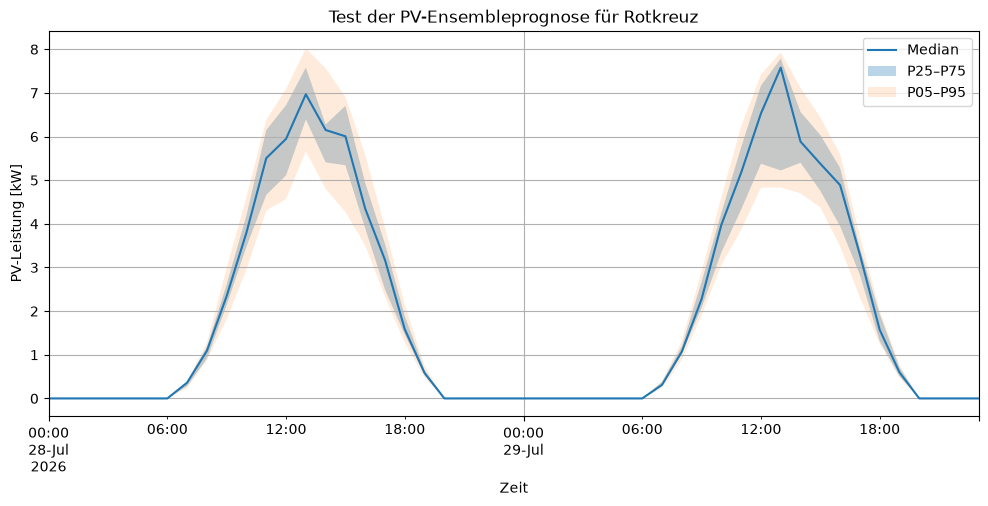

In [15]:
# Testaufruf für calculate_ensemble_quantiles()
# Erzeugt beispielhafte stündliche Wetterprognosen für 20 Ensemble-Mitglieder.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

times = pd.date_range(
    start=pd.Timestamp.now(tz="Europe/Zurich").normalize(),
    periods=48,
    freq="h",
)

ensemble_parts = []

for member_id in range(20):
    hour = times.hour.to_numpy()

    # Vereinfachtes synthetisches Tagesprofil der Globalstrahlung
    daylight_profile = np.maximum(
        0,
        np.sin(np.pi * (hour - 6) / 14),
    )

    cloud_factor = rng.uniform(0.55, 1.0, size=len(times))

    ghi = 850 * daylight_profile * cloud_factor
    dhi = 0.25 * ghi
    dni = np.maximum(0, (ghi - dhi) / 0.75)

    member_weather = pd.DataFrame(
        {
            "ghi": ghi,
            "dni": dni,
            "dhi": dhi,
            "temp_air": 18 + 8 * daylight_profile
            + rng.normal(0, 1, len(times)),
            "wind_speed": np.maximum(
                0.5,
                rng.normal(2.5, 0.6, len(times)),
            ),
            "ensemble_member": member_id,
        },
        index=times,
    )

    ensemble_parts.append(member_weather)

ensemble_weather_test = pd.concat(ensemble_parts)

# Funktion aufrufen
ensemble_quantiles_test = calculate_ensemble_quantiles(
    ensemble_weather=ensemble_weather_test,
    config=ROTKREUZ_PV_CONFIG,
)

display(ensemble_quantiles_test.head(24))

# Plausibilitätsprüfungen
assert not ensemble_quantiles_test.empty
assert ensemble_quantiles_test.index.is_monotonic_increasing
assert (
    ensemble_quantiles_test["p05_kw"]
    <= ensemble_quantiles_test["p25_kw"]
).all()
assert (
    ensemble_quantiles_test["p25_kw"]
    <= ensemble_quantiles_test["median_kw"]
).all()
assert (
    ensemble_quantiles_test["median_kw"]
    <= ensemble_quantiles_test["p75_kw"]
).all()
assert (
    ensemble_quantiles_test["p75_kw"]
    <= ensemble_quantiles_test["p95_kw"]
).all()

print("Test erfolgreich: Quantile sind vollständig und korrekt geordnet.")

# Darstellung
ax = ensemble_quantiles_test["median_kw"].plot(
    figsize=(12, 5),
    label="Median",
)

ax.fill_between(
    ensemble_quantiles_test.index,
    ensemble_quantiles_test["p25_kw"],
    ensemble_quantiles_test["p75_kw"],
    alpha=0.3,
    label="P25–P75",
)

ax.fill_between(
    ensemble_quantiles_test.index,
    ensemble_quantiles_test["p05_kw"],
    ensemble_quantiles_test["p95_kw"],
    alpha=0.15,
    label="P05–P95",
)

ax.set_title("Test der PV-Ensembleprognose für Rotkreuz")
ax.set_xlabel("Zeit")
ax.set_ylabel("PV-Leistung [kW]")
ax.legend()
ax.grid(True)
plt.show()